In [2]:
import numpy as np
import scipy
from scipy.linalg import svd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

In [27]:
import matplotlib.pyplot as plt

plt.style.use("IEEEstyle.mplstyle")

def construct_properties_dict(names, labels):

    """

    names: data variables
    labels: Corresponding consistent labels to be used for them throughout

    """

    linestyles = ['solid', 'dashed', 'dashdot', 'dotted', 'solid', 'solid']
    colors = ['blue', 'brown', 'purple', 'darkorange', 'green', 'red']
    markers = ['o', '^', 's', 'P', 'X', '*']

    properties_dict = {}

    for i, name in enumerate(names):
        properties_dict[name] = {
            'color': colors[i],
            'linestyle': linestyles[i],
            'marker': markers[i],
            'label': labels[i]
        }

    return properties_dict

properties_dict = construct_properties_dict(['Add-constant', 'Jelinek-Mercer', 'Kneser-Ney', 'Semantic k=5', 'Semantic k=10'], ['Add-constant', 'Jelinek-Mercer', 'Kneser-Ney', 'Semantic Smoothing (m = 5)', 'Semantic Smoothing (m = 10)'])
properties_dict_2 = construct_properties_dict(['Add-constant', 'Semantic k=5', 'Semantic k=10', 'Semantic k=15', 'Semantic k=20'], ['Add-constant', 'Semantic Smoothing 5 synonyms', 'Semantic Smoothing 10 synonyms', 'Semantic Smoothing 15 synonyms', 'Semantic Smoothing 20 synonyms'])

In [4]:
class MarkovChain:
    def __init__(self, P, seed=None):
        """
        Initialize a Markov chain with a given transition matrix.

        Args:
            P (array-like): d x d transition matrix (rows must sum to 1)
            seed (int, optional): random seed
        """
        self.P = np.array(P, dtype=float)
        self.d = self.P.shape[0]
        self.rng = np.random.default_rng(seed)
        self._validate_transition_matrix()

        self.pi = self._stationary_distribution()

    def _validate_transition_matrix(self):
        """
        Ensure P is a valid row-stochastic matrix.
        """
        if self.P.shape[0] != self.P.shape[1]:
            raise ValueError("Transition matrix must be square.")

        if np.any(self.P < 0):
            raise ValueError("Transition probabilities must be non-negative.")

        row_sums = self.P.sum(axis=1)
        if not np.allclose(row_sums, 1):
            raise ValueError("Each row must sum to 1.")

    def _stationary_distribution(self):
        """
        Compute stationary distribution π such that πP = π.
        """
        eigvals, eigvecs = np.linalg.eig(self.P.T)
        idx = np.argmin(np.abs(eigvals - 1))
        pi = np.real(eigvecs[:, idx])
        pi = pi / np.sum(pi)
        return pi

    def sample(self, n, start_state=None):
        """
        Generate n samples from the Markov chain.
        """
        if start_state is None:
            start_state = self.rng.integers(self.d)

        samples = [start_state]
        current = start_state

        for _ in range(n - 1):
            current = self.rng.choice(self.d, p=self.P[current])
            samples.append(current)

        return samples

In [5]:
def random_transition_matrix(d, seed=None):
    """
    Generate a random d x d row-stochastic matrix.

    Args:
        d (int): number of states
        seed (int, optional): random seed

    Returns:
        P (numpy array): d x d transition matrix
    """
    rng = np.random.default_rng(seed)

    # Generate random positive entries
    M = rng.random((d, d))

    # Normalize rows to sum to 1
    P = M / M.sum(axis=1, keepdims=True)

    return P

In [6]:
def compute_embedding(P, dim):
    """
    Compute node embeddings by SVD and extract U_k and V_k vectors.

    Returns:
        U_k: (d x dim) embeddings
        v_max: (d,) vector from V_k with largest ℓ∞ norm
    """
    d = P.shape[0]

    # Step 1: multi-step transitions
    M = P
    Pk = np.eye(d)

    # Step 2: stationary distribution
    eigvals, eigvecs = np.linalg.eig(P.T)
    pi = np.real(eigvecs[:, np.argmax(np.real(eigvals))])
    pi = pi / pi.sum()

    # Step 3: PMI matrix
    eps = 1e-12
    M = M + eps
    pi = pi + eps

    PMI = np.log(M) - np.log(pi.reshape(1, -1))

    # Step 4: SVD
    U, S, Vt = svd(PMI)

    # Left embeddings
    U_k = U[:, :dim] * np.sqrt(S[:dim])

    # Right singular vectors (top-k)
    V_k = (Vt[:dim, :].T) * np.sqrt(S[:dim])

    return U_k, V_k

In [7]:
class AddConstantMarkovEstimator:
    def __init__(self, d, alpha=0.5):
        """
        Args:
            d (int): number of states
            alpha (float): smoothing constant (Laplace if alpha=1)
        """
        self.d = d
        self.alpha = alpha
        self.P_hat = None

    def fit(self, data):
        """
        Estimate transition matrix from sequence data.

        Args:
            data (list or array): sequence of states
        """
        counts = np.zeros((self.d, self.d))

        # Count transitions
        for i in range(len(data) - 1):
            u = data[i]
            v = data[i + 1]
            counts[u, v] += 1

        # Add-constant smoothing
        counts += self.alpha

        # Normalize rows
        row_sums = counts.sum(axis=1, keepdims=True)
        self.P_hat = counts / row_sums

    def perplexity(self, data):
        """
        Compute perplexity on test data.

        Args:
            data (list or array): test sequence

        Returns:
            perplexity (float)
        """
        if self.P_hat is None:
            raise ValueError("Model must be fit before computing perplexity.")

        log_likelihood = 0.0
        T = len(data) - 1

        for i in range(T):
            u = data[i]
            v = data[i + 1]
            p = self.P_hat[u, v]

            # numerical safety
            log_likelihood += np.log(p + 1e-12)

        avg_log_likelihood = log_likelihood / T

        perplexity = np.exp(-avg_log_likelihood)
        return perplexity

In [8]:
class KneserNeyMarkovEstimator:
    def __init__(self, d, D=0.75):
        """
        Args:
            d (int): number of states
            D (float): discount parameter
        """
        self.d = d
        self.D = D
        self.P_hat = None

    def fit(self, data):
        """
        Estimate transition probabilities using Kneser-Ney smoothing.
        """
        counts = np.zeros((self.d, self.d))

        # Count transitions
        for i in range(len(data) - 1):
            u = data[i]
            v = data[i + 1]
            counts[u, v] += 1

        N_u = counts.sum(axis=1)  # row sums

        # Number of unique continuations per u
        unique_continuations = (counts > 0).sum(axis=1)

        # Continuation counts for each v
        continuation_counts = (counts > 0).sum(axis=0)

        total_continuations = continuation_counts.sum()

        # Continuation probability
        P_cont = continuation_counts / total_continuations

        # Build P_hat
        P_hat = np.zeros_like(counts)

        for u in range(self.d):
            if N_u[u] == 0:
                # fallback: use continuation distribution
                P_hat[u] = P_cont
                continue

            lambda_u = (self.D * unique_continuations[u]) / N_u[u]

            for v in range(self.d):
                first_term = max(counts[u, v] - self.D, 0) / N_u[u]
                P_hat[u, v] = first_term + lambda_u * P_cont[v]

        self.P_hat = P_hat

    def perplexity(self, data):
        """
        Compute perplexity on test data.
        """
        if self.P_hat is None:
            raise ValueError("Model must be fit first.")

        log_likelihood = 0.0
        T = len(data) - 1

        for i in range(T):
            u = data[i]
            v = data[i + 1]
            p = self.P_hat[u, v]

            log_likelihood += np.log(p + 1e-12)

        avg_log_likelihood = log_likelihood / T
        return np.exp(-avg_log_likelihood)

In [9]:
class JelinekMercerMarkovEstimator:
    def __init__(self, d, lam=0.1):
        """
        Args:
            d (int): number of states
            lam (float): interpolation parameter (lambda)
        """
        self.d = d
        self.lam = lam
        self.P_hat = None

    def fit(self, data):
        """
        Estimate transition probabilities using Jelinek-Mercer smoothing.
        """
        counts = np.zeros((self.d, self.d))

        # Count transitions
        for i in range(len(data) - 1):
            u = data[i]
            v = data[i + 1]
            counts[u, v] += 1

        # Row sums (for MLE)
        N_u = counts.sum(axis=1, keepdims=True)

        # MLE transition probabilities
        with np.errstate(divide='ignore', invalid='ignore'):
            P_mle = counts / N_u
            P_mle[np.isnan(P_mle)] = 0.0  # handle rows with no transitions

        # Unigram distribution
        total = counts.sum()
        unigram = counts.sum(axis=0) / total

        # Interpolation
        P_hat = (1 - self.lam) * P_mle + self.lam * unigram.reshape(1, -1)

        self.P_hat = P_hat

    def perplexity(self, data):
        """
        Compute perplexity on test data.
        """
        if self.P_hat is None:
            raise ValueError("Model must be fit first.")

        log_likelihood = 0.0
        T = len(data) - 1

        for i in range(T):
            u = data[i]
            v = data[i + 1]
            p = self.P_hat[u, v]

            log_likelihood += np.log(p + 1e-12)

        avg_log_likelihood = log_likelihood / T
        return np.exp(-avg_log_likelihood)

In [10]:
def empirical_conditional_perplexity(data, d):
    counts = np.zeros((d, d))

    for i in range(len(data) - 1):
        u, v = data[i], data[i + 1]
        counts[u, v] += 1

    total = counts.sum()

    # Joint distribution
    joint = counts / total

    # Row sums
    N_u = counts.sum(axis=1, keepdims=True)

    # Conditional probabilities (safe)
    P = np.zeros_like(counts)
    mask = N_u > 0
    P[mask[:, 0]] = counts[mask[:, 0]] / N_u[mask[:, 0]]

    # Only compute where counts > 0 (IMPORTANT FIX)
    mask_nonzero = counts > 0

    entropy = -np.sum(
        joint[mask_nonzero] * np.log(P[mask_nonzero])
    )

    perplexity = np.exp(entropy)

    return perplexity

In [11]:
def repeated_random_row_markov_matrix(d, rank, seed=None, cluster_sizes=None, shuffle=True):
    """
    Generate a d x d Markov transition matrix with only `rank` distinct rows.

    Steps:
        1. Generate `rank` random transition rows.
        2. Copy those rows across the d states.

    Args:
        d (int): number of states
        rank (int): number of distinct transition rows
        seed (int, optional): random seed
        cluster_sizes (list[int], optional): how many times to copy each row.
            Must have length `rank` and sum to d.
        shuffle (bool): whether to shuffle state labels

    Returns:
        P: d x d Markov transition matrix
        labels: array of length d, saying which prototype row each state uses
        prototypes: rank x d matrix of the distinct transition rows
    """
    rng = np.random.default_rng(seed)

    if rank > d:
        raise ValueError("rank must be <= d")

    if cluster_sizes is None:
        base = d // rank
        rem = d % rank
        cluster_sizes = [base + (k < rem) for k in range(rank)]

    if len(cluster_sizes) != rank:
        raise ValueError("cluster_sizes must have length rank")

    if sum(cluster_sizes) != d:
        raise ValueError("cluster_sizes must sum to d")

    # Generate rank random rows of a transition matrix
    prototypes = rng.random((rank, d))
    prototypes = prototypes / prototypes.sum(axis=1, keepdims=True)

    # Copy rows
    labels = np.concatenate([
        np.full(size, k, dtype=int)
        for k, size in enumerate(cluster_sizes)
    ])

    if shuffle:
        rng.shuffle(labels)

    P = prototypes[labels]

    return P

In [12]:
d = 100
rank = 10

P = repeated_random_row_markov_matrix(
    d=d,
    rank=rank,
    shuffle=False
)

mc = MarkovChain(P)
print(P)

[[0.01697169 0.02040313 0.02053141 ... 0.00048571 0.00198797 0.00052036]
 [0.01697169 0.02040313 0.02053141 ... 0.00048571 0.00198797 0.00052036]
 [0.01697169 0.02040313 0.02053141 ... 0.00048571 0.00198797 0.00052036]
 ...
 [0.00391733 0.0066769  0.00681599 ... 0.00026618 0.01480784 0.00702157]
 [0.00391733 0.0066769  0.00681599 ... 0.00026618 0.01480784 0.00702157]
 [0.00391733 0.0066769  0.00681599 ... 0.00026618 0.01480784 0.00702157]]


In [13]:
U_k, V_k = compute_embedding(P, rank)

In [14]:
n_train = 50000
train_data = mc.sample(n_train)

In [15]:
n_test = 5000000
test_data = mc.sample(n_test)

In [16]:
print(np.shape(U_k), np.shape(V_k))

l2_norms = np.linalg.norm(V_k, ord = 2, axis=1)
idx = np.argmax(l2_norms)
v_max = np.max(l2_norms)

l2_norms = np.linalg.norm(U_k, ord = 2, axis=1)
idx = np.argmax(l2_norms)
u_max = np.max(l2_norms)

print(v_max, u_max)

(100, 10) (100, 10)
4.26906287958656 1.9111676724058444


In [17]:
estimator = AddConstantMarkovEstimator(d, alpha=1.0)
estimator.fit(train_data)
add_c_pp = estimator.perplexity(test_data)

print("Perplexity:", add_c_pp)

Perplexity: 89.20559721702307


In [18]:
kn = KneserNeyMarkovEstimator(d, D=0.75)

kn.fit(train_data[:d * d])

kn_pp = kn.perplexity(test_data)

print("Kneser-Ney Perplexity:", kn_pp)

Kneser-Ney Perplexity: 107.41068692378128


In [19]:
jm = JelinekMercerMarkovEstimator(d, lam=0.1)

jm.fit(train_data)

jm_pp = jm.perplexity(test_data)

print("Jelinek-Mercer Perplexity:", jm_pp)

Jelinek-Mercer Perplexity: 90.31017557968879


In [20]:
lb_pp = empirical_conditional_perplexity(test_data, d)

print("Lower bound perplexity:", lb_pp)

Lower bound perplexity: 82.32551899005418


In [21]:
class SemanticDistributionEstimator:
    def __init__(self, U, d, max_value, k=5, alpha=1.0, beta=1.0):
        """
        Args:
            U (array): (d, m) embeddings
            d (int): number of states
            max_value (float): Lipschitz constant
            k (int): number of synonyms
            alpha (float): add-constant smoothing parameter
            beta (float): softmin temperature
        """
        self.U = U
        self.d = d
        self.L = max_value
        self.k = k
        self.alpha = alpha
        self.beta = beta
        self.P_hat = None

    def _compute_add_constant(self, data):
        counts = np.zeros((self.d, self.d))

        # Count transitions
        for i in range(len(data) - 1):
            u, v = data[i], data[i + 1]
            counts[u, v] += 1

        # Save raw counts BEFORE smoothing
        raw_counts = counts.copy()

        # Add-constant smoothing
        counts += self.alpha

        row_sums = counts.sum(axis=1, keepdims=True)
        P_base = counts / row_sums

        # Recover N_s (true counts per state)
        N_s = raw_counts.sum(axis=1)  # shape (d,)

        return P_base, N_s

    def fit(self, data):
        P_base, N_s = self._compute_add_constant(data)
        P_hat = np.zeros_like(P_base)

        # Precompute all pairwise L1 distances (efficient)
        # shape: (d, d)

        l2_dist_matrix = np.linalg.norm(
            self.U[:, None, :] - self.U[None, :, :],
            axis=2, ord = 2
        )

        delta_matrix = self.L * l2_dist_matrix

        # Avoid division by zero
        N_s_safe = N_s + 1e-12

        # Confidence penalty
        penalty = self.d / N_s_safe  # shape (d,)

        # Broadcast penalty across rows
        score_matrix = delta_matrix + penalty.reshape(1, -1)

        for u in range(self.d):
            scores = score_matrix[u]

            if self.k == 0:
                # Only use the word itself (no smoothing)
                topk_idx = np.array([u])
            else:
                # Get k-1 nearest OTHER neighbors
                sorted_idx = np.argsort(scores)

                # Remove u first
                sorted_idx = sorted_idx[sorted_idx != u]

                k_eff = min(self.k - 1, self.d - 1)

                neighbors = sorted_idx[:k_eff]

                # Always include u
                topk_idx = np.concatenate(([u], neighbors))

            topk_scores = scores[topk_idx]

            # Softmin weights
            scaled = -self.beta * topk_scores
            scaled -= np.max(scaled)

            weights = np.exp(scaled)
            weights /= weights.sum()

            # Interpolate
            P_hat[u] = weights @ P_base[topk_idx]

        self.P_hat = P_hat

    def perplexity(self, data):
        if self.P_hat is None:
            raise ValueError("Model must be fit first.")

        log_likelihood = 0.0
        T = len(data) - 1

        for i in range(T):
            u, v = data[i], data[i + 1]
            p = self.P_hat[u, v]
            log_likelihood += np.log(p + 1e-12)

        avg_log_likelihood = log_likelihood / T
        return np.exp(-avg_log_likelihood)

## One Stochastic sample of n_train

In [22]:
# Sample sizes to test
n_values = np.array([10000, 30000, 100000, 300000, 1000000])

# Semantic hyperparameters
k_values = np.array(range(5, 11, 5))
beta = 1

results = {}

# Baseline models
results["Add-constant"] = []
results["Jelinek-Mercer"] = []
results["Kneser-Ney"] = []

# Semantic models
for k in k_values:
    results[f"Semantic k={k}"] = []


for n in n_values:
    print(f"\n=== n = {n} ===")

    _train_data = mc.sample(n)

    # ------------------------------------------------------------
    # Add-constant
    # ------------------------------------------------------------
    add_const = AddConstantMarkovEstimator(d, alpha=0.1)
    add_const.fit(_train_data)
    pp_add = add_const.perplexity(test_data)
    results["Add-constant"].append(pp_add)

    # ------------------------------------------------------------
    # Jelinek-Mercer
    # ------------------------------------------------------------
    jm = JelinekMercerMarkovEstimator(d, lam=0.1)
    jm.fit(_train_data)
    pp_jm = jm.perplexity(test_data)
    results["Jelinek-Mercer"].append(pp_jm)

    # ------------------------------------------------------------
    # Kneser-Ney
    # ------------------------------------------------------------
    kn = KneserNeyMarkovEstimator(d, D=0.75)
    kn.fit(_train_data)
    pp_kn = kn.perplexity(test_data)
    results["Kneser-Ney"].append(pp_kn)

    print(f"Add-constant:     {pp_add:.4f}")
    # print(f"Jelinek-Mercer:   {pp_jm:.4f}")
    # print(f"Kneser-Ney:       {pp_kn:.4f}")

    # ------------------------------------------------------------
    # Semantic estimators for different k
    # ------------------------------------------------------------
    for k in k_values:
        semantic_model = SemanticDistributionEstimator(
            U_k,
            d,
            v_max,
            k=k,
            alpha=1/(d * d),
            beta=beta,
        )

        semantic_model.fit(_train_data)
        pp_sem = semantic_model.perplexity(test_data)

        results[f"Semantic k={k}"].append(pp_sem)

        print(f"Semantic k={k}:   {pp_sem:.4f}")


=== n = 10000 ===
Add-constant:     145.7416
Semantic k=5:   101.3909
Semantic k=10:   88.4181

=== n = 30000 ===
Add-constant:     101.6155
Semantic k=5:   86.2026
Semantic k=10:   84.1550

=== n = 100000 ===
Add-constant:     87.0654
Semantic k=5:   83.1466
Semantic k=10:   82.8415

=== n = 300000 ===
Add-constant:     83.9014
Semantic k=5:   82.6720
Semantic k=10:   82.5585

=== n = 1000000 ===
Add-constant:     82.8329
Semantic k=5:   82.4873
Semantic k=10:   82.4549


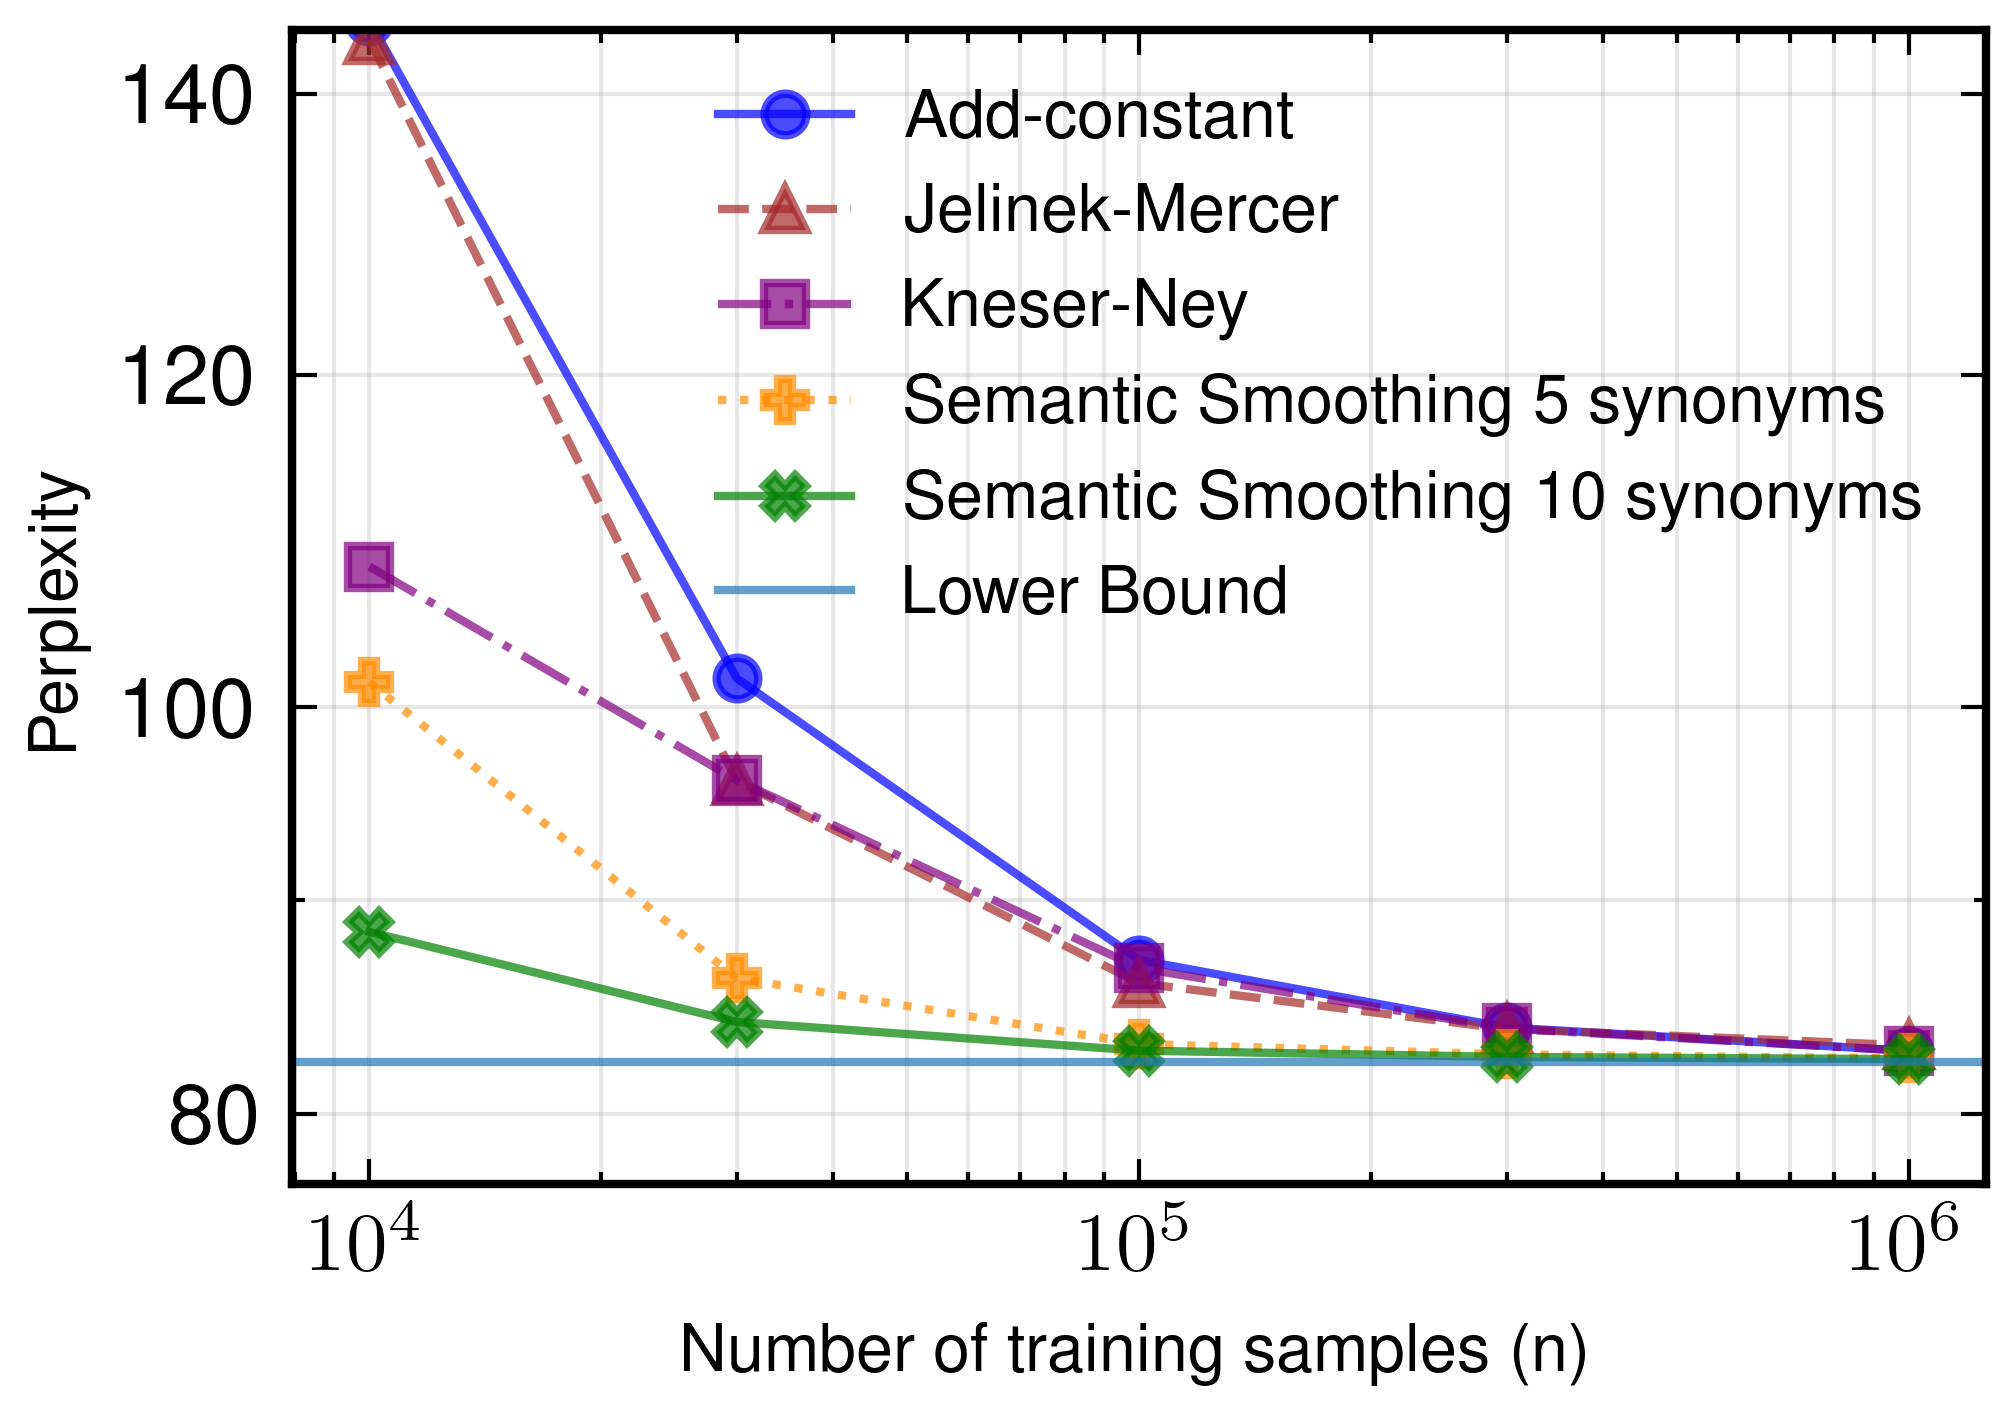

In [23]:
plt.figure()

for i, (model_name, perplexities) in enumerate(results.items()):

    plt.plot(
        n_values,
        perplexities,
        marker=properties_dict[model_name]['marker'],
        linestyle=properties_dict[model_name]['linestyle'],
        color=properties_dict[model_name]['color'],
        label=properties_dict[model_name]['label'],
        alpha=0.7
    )

pp_lower = empirical_conditional_perplexity(test_data, d)
plt.axhline(pp_lower, label="Lower Bound", alpha=0.7)

plt.xlabel("Number of training samples (n)")
plt.ylabel("Perplexity")

plt.xscale("log")
plt.yscale("log")
plt.ylim(77, 145)

ax = plt.gca()
ax.yaxis.set_major_locator(mticker.FixedLocator([80, 100, 120, 140]))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y)}"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

plt.grid(True, which="both", alpha=0.3)

plt.legend(loc='upper right', frameon=False)
plt.tight_layout()

plt.savefig('synthetic_simulations.pdf', backend='pgf')
plt.show()

## 10 Stochastic samples of n_train

In [24]:
# Sample sizes to test
n_values = np.array([10000, 30000, 100000, 300000, 1000000])

# Semantic hyperparameters
k_values = np.array(range(5, 11, 5))
beta = 1

# Number of repeated trials for each n
n_repeats = 10

# Store raw results across repetitions
raw_results = {}

# Baseline models
raw_results["Add-constant"] = [[] for _ in n_values]
raw_results["Jelinek-Mercer"] = [[] for _ in n_values]
raw_results["Kneser-Ney"] = [[] for _ in n_values]

# Semantic models
for k in k_values:
    raw_results[f"Semantic k={k}"] = [[] for _ in n_values]


for idx, n in enumerate(n_values):
    print(f"\n=== n = {n} ===")

    for rep in range(n_repeats):
        print(f"  Trial {rep + 1}/{n_repeats}")

        _train_data = mc.sample(n)

        # ------------------------------------------------------------
        # Add-constant
        # ------------------------------------------------------------
        add_const = AddConstantMarkovEstimator(d, alpha=0.1)
        add_const.fit(_train_data)
        pp_add = add_const.perplexity(test_data)
        raw_results["Add-constant"][idx].append(pp_add)

        # ------------------------------------------------------------
        # Jelinek-Mercer
        # ------------------------------------------------------------
        jm = JelinekMercerMarkovEstimator(d, lam=0.1)
        jm.fit(_train_data)
        pp_jm = jm.perplexity(test_data)
        raw_results["Jelinek-Mercer"][idx].append(pp_jm)

        # ------------------------------------------------------------
        # Kneser-Ney
        # ------------------------------------------------------------
        kn = KneserNeyMarkovEstimator(d, D=0.75)
        kn.fit(_train_data)
        pp_kn = kn.perplexity(test_data)
        raw_results["Kneser-Ney"][idx].append(pp_kn)

        # ------------------------------------------------------------
        # Semantic estimators for different k
        # ------------------------------------------------------------
        for k in k_values:
            semantic_model = SemanticDistributionEstimator(
                U_k,
                d,
                v_max,
                k=k,
                alpha=1/(d * d),
                beta=beta,
            )

            semantic_model.fit(_train_data)
            pp_sem = semantic_model.perplexity(test_data)
            raw_results[f"Semantic k={k}"][idx].append(pp_sem)

    # Optional summary printout after all repetitions for this n
    print(f"Add-constant:   mean={np.mean(raw_results['Add-constant'][idx]):.4f}, std={np.std(raw_results['Add-constant'][idx]):.4f}")
    print(f"Jelinek-Mercer: mean={np.mean(raw_results['Jelinek-Mercer'][idx]):.4f}, std={np.std(raw_results['Jelinek-Mercer'][idx]):.4f}")
    print(f"Kneser-Ney:     mean={np.mean(raw_results['Kneser-Ney'][idx]):.4f}, std={np.std(raw_results['Kneser-Ney'][idx]):.4f}")
    for k in k_values:
        vals = raw_results[f"Semantic k={k}"][idx]
        print(f"Semantic k={k}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}")



=== n = 10000 ===
  Trial 1/10
  Trial 2/10
  Trial 3/10
  Trial 4/10
  Trial 5/10
  Trial 6/10
  Trial 7/10
  Trial 8/10
  Trial 9/10
  Trial 10/10
Add-constant:   mean=144.5486, std=1.4833
Jelinek-Mercer: mean=142.6268, std=1.4955
Kneser-Ney:     mean=107.7807, std=0.5788
Semantic k=5: mean=100.0616, std=1.6927
Semantic k=10: mean=89.1929, std=0.6646

=== n = 30000 ===
  Trial 1/10
  Trial 2/10
  Trial 3/10
  Trial 4/10
  Trial 5/10
  Trial 6/10
  Trial 7/10
  Trial 8/10
  Trial 9/10
  Trial 10/10
Add-constant:   mean=102.1962, std=0.4201
Jelinek-Mercer: mean=96.3734, std=0.2681
Kneser-Ney:     mean=96.2364, std=0.1936
Semantic k=5: mean=85.8649, std=0.1359
Semantic k=10: mean=84.1282, std=0.1626

=== n = 100000 ===
  Trial 1/10
  Trial 2/10
  Trial 3/10
  Trial 4/10
  Trial 5/10
  Trial 6/10
  Trial 7/10
  Trial 8/10
  Trial 9/10
  Trial 10/10
Add-constant:   mean=87.2537, std=0.0768
Jelinek-Mercer: mean=86.0660, std=0.0518
Kneser-Ney:     mean=86.7905, std=0.0547
Semantic k=5: mea

In [25]:
pp_lower = empirical_conditional_perplexity(test_data, d)   

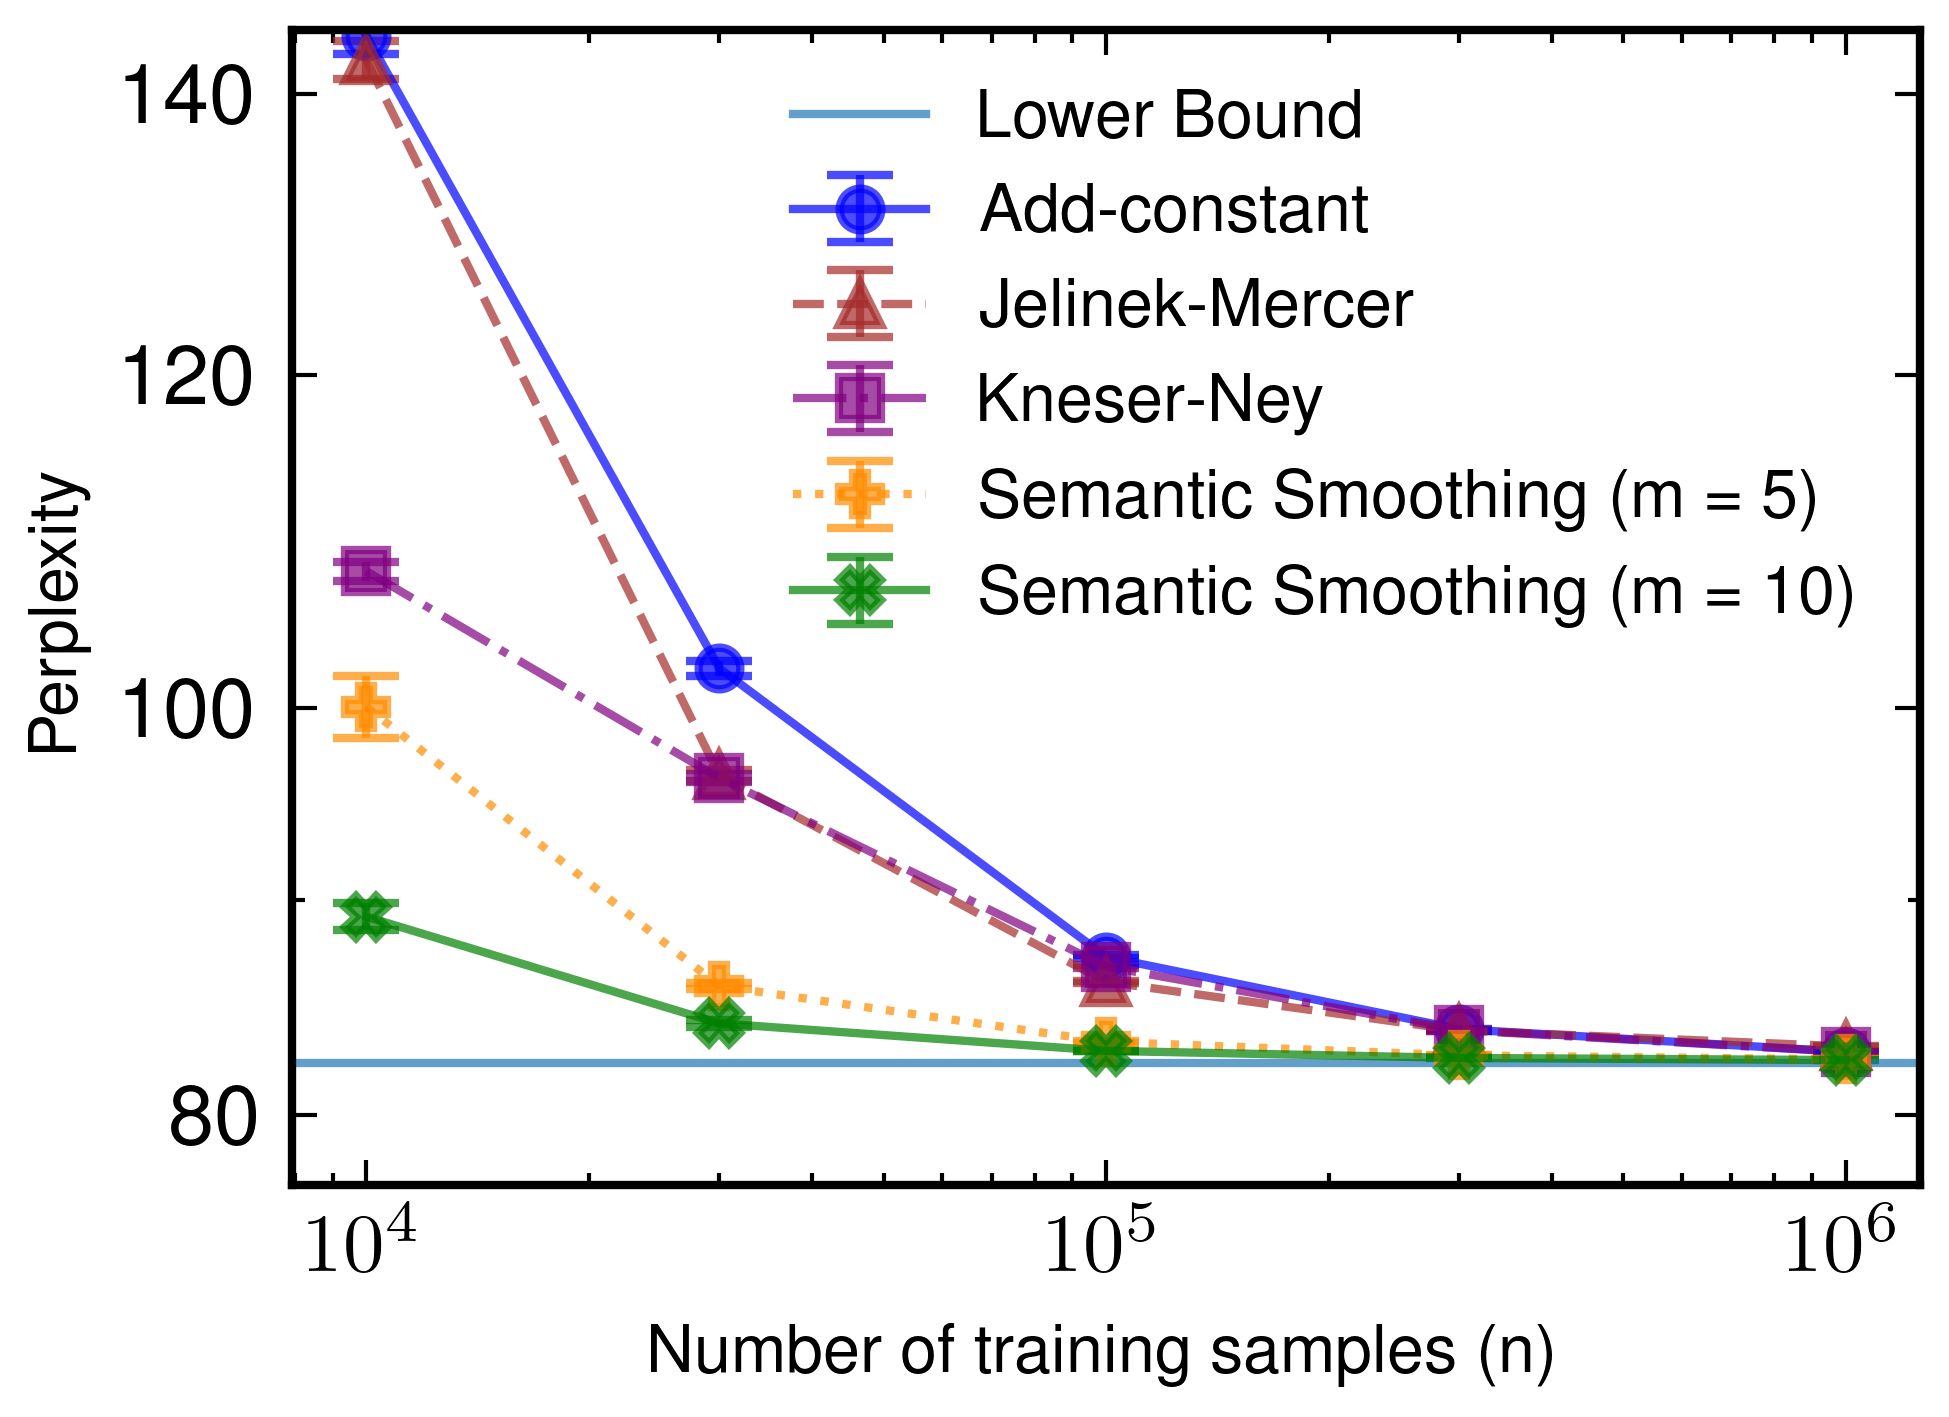

In [28]:
# Aggregate mean and std
results_mean = {}
results_std = {}

for model_name, values_by_n in raw_results.items():
    results_mean[model_name] = [np.mean(vals) for vals in values_by_n]
    results_std[model_name] = [np.std(vals) for vals in values_by_n]
    # If you want standard error instead of std, use:
    # results_std[model_name] = [np.std(vals) / np.sqrt(len(vals)) for vals in values_by_n]

plt.figure(figsize=(3.5, 2.5))


for model_name in results_mean:
    plt.errorbar(
        n_values,
        results_mean[model_name],
        yerr=results_std[model_name],
        marker=properties_dict[model_name]['marker'],
        linestyle=properties_dict[model_name]['linestyle'],
        color=properties_dict[model_name]['color'],
        label=properties_dict[model_name]['label'],
        alpha=0.7,
        capsize=4
    )

plt.axhline(pp_lower, label="Lower Bound", alpha=0.7)

plt.xlabel("Number of training samples (n)")
plt.ylabel("Perplexity")

plt.xscale("log")
plt.yscale("log")
plt.ylim(77, 145)

ax = plt.gca()
ax.yaxis.set_major_locator(mticker.FixedLocator([80, 100, 120, 140]))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{int(y)}"))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='upper right', frameon=False)
plt.savefig('synthetic_simulations_error_bars.pdf', backend='pgf')
plt.show()